<a href="https://colab.research.google.com/github/Jackline-Jebet/Streaming-Analytics-NLP-Pipeline-ML-/blob/main/Data_Streaming_analytics_using_PySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, col, udf, size
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

In [ ]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("WordFrequencyDiscounting") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

In [ ]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the large corpus (14M words, subsample to ~10M)
data = spark.read.text('drive/My Drive/Colab Notebooks/corpus.txt')
data = data.selectExpr("explode(split(value, ' ')) as word").filter(col("word") != "")
large_corpus = data.sample(withReplacement=False, fraction=10.0/14.0)  # Approx. 10M words
print(f"Large corpus size (estimated words): {large_corpus.count()}")

Large corpus size (estimated words): 10037292


In [ ]:
# Create subsets of different sizes
sizes = [1000, 10000, 100000, 1000000]
subsets = {}
for size in sizes:
    subset = data.sample(withReplacement=False, fraction=size/large_corpus.count()).limit(size)
    subsets[size] = subset
    print(f"Subset {size} words created with {subset.count()} words")

Subset 1000 words created with 1000 words
Subset 10000 words created with 10000 words
Subset 100000 words created with 100000 words
Subset 1000000 words created with 1000000 words


In [ ]:
# Function to compute raw word frequencies
def compute_frequencies(df):
    return df.groupBy("word").count().withColumnRenamed("count", "frequency")

In [ ]:
# Compute frequencies for large corpus
large_freq = compute_frequencies(large_corpus).cache()
print("Sample of large corpus frequencies:")
large_freq.show(20)

Sample of large corpus frequencies:
+---------+---------+
|     word|frequency|
+---------+---------+
|   Friday|     2582|
|Atlanta's|        9|
| produced|      550|
|     that|    82122|
|   place.|      249|
|      The|    59804|
|     said|    45254|
|     City|     1218|
|Executive|     1196|
| Atlanta"|        4|
|      for|    95753|
|    Court|     1306|
|       to|   273230|
| possible|     1982|
| relative|      584|
|  handful|      241|
|     such|     8459|
|   voters|      614|
|     size|      829|
| election|     2305|
+---------+---------+
only showing top 20 rows



In [ ]:
# Discounting methods
from pyspark.sql.functions import when

def good_turing_discount(freq_df, total_words):
    # Compute n_c (count of counts)
    freq_counts = freq_df.groupBy("frequency").count().withColumnRenamed("count", "n_c")
    n_1_row = freq_counts.filter(col("frequency") == 1).select("n_c").collect()
    n_1 = n_1_row[0][0] if n_1_row else 0

    # Apply Good-Turing adjustment using when
    return freq_df.withColumn("adjusted_freq",
                              when(col("frequency") == 1, (col("frequency") + 1) * (n_1 / total_words))
                             .otherwise(col("frequency")))


# Laplace Smoothing Function
def laplace_smoothing(freq_df, vocab_size):
    return freq_df.withColumn("adjusted_freq", (col("frequency") + 1) / (vocab_size + freq_df.count()))

def katz_backoff(freq_df, total_words, discount=0.75):
    return freq_df.withColumn("adjusted_freq", col("frequency") * discount)

In [ ]:
# Apply discounting and evaluate
from pyspark.sql.types import IntegerType
from pyspark.sql.functions import udf

results = {}
for size in [10000000] + sizes:
    df = large_corpus if size == 10000000 else subsets[size]
    freq_df = compute_frequencies(df).cache()
    vocab_size = freq_df.count()
    total_words = df.count()

    gt_df = good_turing_discount(freq_df, total_words)
    ls_df = laplace_smoothing(freq_df, vocab_size)
    kb_df = katz_backoff(freq_df, total_words)

    results[size] = {"gt": gt_df, "ls": ls_df, "kb": kb_df}


In [ ]:
# Evaluation with clustering against large corpus
from pyspark.sql.functions import avg, abs

large_freq_dict = large_freq.select("word", "frequency").rdd.collectAsMap()
eval_results = {}
for size in sizes:
    for method in ["gt", "ls", "kb"]:
        subset_df = results[size][method].select("word", "adjusted_freq")
        joined_df = subset_df.join(
            large_freq.withColumnRenamed("frequency", "large_freq"),
            "word",
            "left_outer"
        )
        # Add 'error' column (absolute difference)
        joined_df = joined_df.filter(col("large_freq").isNotNull()) \
                             .withColumn("error", abs(col("adjusted_freq") - col("large_freq")))

        mae = joined_df.agg(avg("error")).collect()[0][0]
        eval_results[(size, method)] = mae if mae is not None else float('inf')

        print(f"MAE for {size} words with {method}: {eval_results[(size, method)]}")


MAE for 1000 words with gt: 6518.789560747697
MAE for 1000 words with ls: 6520.415479212326
MAE for 1000 words with kb: 6519.256230529595
MAE for 10000 words with gt: 1479.7209407407997
MAE for 10000 words with ls: 1481.7346990285728
MAE for 10000 words with kb: 1480.0478300386276
MAE for 100000 words with gt: 366.3544956485643
MAE for 100000 words with ls: 370.2594950282033
MAE for 100000 words with kb: 366.98961124533275
MAE for 1000000 words with gt: 86.58257942687719
MAE for 1000000 words with ls: 96.19658460240653
MAE for 1000000 words with kb: 88.59354080433339


In [ ]:
# KMeans clustering on frequency differences

assembler = VectorAssembler(inputCols=["adjusted_freq", "large_freq_val"], outputCol="features")

for size in sizes:
    for method in ["gt", "ls", "kb"]:
        # Rename large_freq.frequency to avoid ambiguity
        freq_joined = results[size][method].join(
            large_freq.withColumnRenamed("frequency", "large_freq_val"),
            "word",
            "left_outer"
        ).na.fill(0)

        clustered_df = assembler.transform(freq_joined)

        kmeans = KMeans(k=3, seed=42)
        model = kmeans.fit(clustered_df.select("features"))
        clusters = model.transform(clustered_df)

        print(f"Cluster centers for {size} words with {method}:")
        for center in model.clusterCenters():
            print(f"  Center: {center}")

        clusters.select("word", "adjusted_freq", "large_freq_val", "prediction").show(5)

Cluster centers for 1000 words with gt:
  Center: [1.24983117e+00 2.08340747e+03]
  Center: [2.70000000e+01 2.71629833e+05]
  Center: [4.78100000e+00 4.89596154e+04]
+-------+-------------+--------------+----------+
|   word|adjusted_freq|large_freq_val|prediction|
+-------+-------------+--------------+----------+
|weekend|        1.102|           432|         0|
|Central|        1.102|          1602|         0|
|   left|        1.102|          2459|         0|
|   must|        1.102|          2791|         0|
| former|          2.0|          3924|         0|
+-------+-------------+--------------+----------+
only showing top 5 rows

Cluster centers for 1000 words with ls:
  Center: [1.66596521e-03 2.08340747e+03]
  Center: [2.16049383e-02 2.71629833e+05]
  Center: [4.45156695e-03 4.89596154e+04]
+-------+--------------------+--------------+----------+
|   word|       adjusted_freq|large_freq_val|prediction|
+-------+--------------------+--------------+----------+
|weekend|0.00154320987

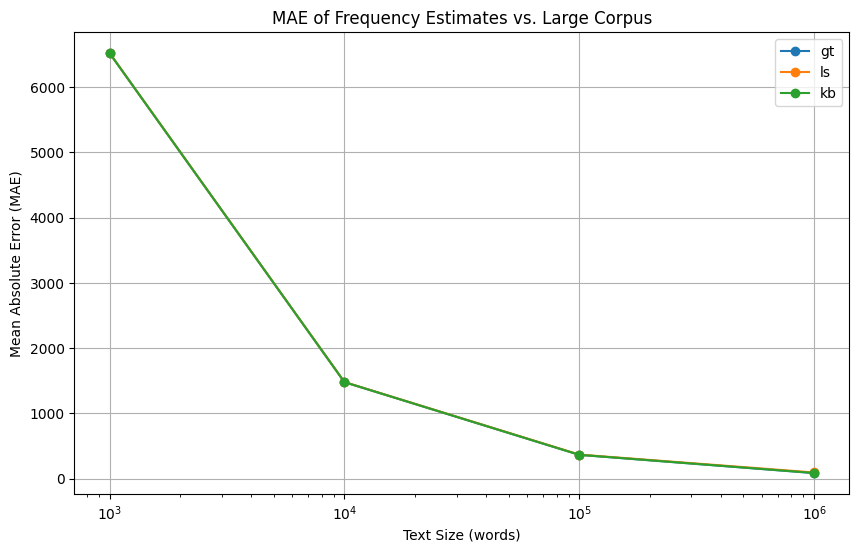

In [ ]:
# Visualization
sizes_list = [1000, 10000, 100000, 1000000]
methods = ["gt", "ls", "kb"]
mae_values = {size: [eval_results[(size, m)] for m in methods] for size in sizes_list}

plt.figure(figsize=(10, 6))
for i, method in enumerate(methods):
    plt.plot(sizes_list, [mae_values[size][i] for size in sizes_list], marker='o', label=method)
plt.xscale("log")
plt.xlabel("Text Size (words)")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("MAE of Frequency Estimates vs. Large Corpus")
plt.legend()
plt.grid(True)
plt.savefig("frequency_mae_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Stop Spark session
spark.stop()